# 05 — Feedback Stabilization: Damping, Pole Placement, LQR and MPC

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *How can a control computed from the current state make a system converge to equilibrium?*

Notebooks 02–04 built open-loop controls: functions of time, computed from the model before anything happens. **Feedback reacts to the current state instead.** Notebook 01 *observed* the overdamping paradox; here we place it inside a theory — when does feedback stabilize, how fast, what limits the speed, and how a cost function can choose the feedback for us.

### Table of Contents

1. **The stabilization problem** — what linear feedback can and cannot do
2. **The feedback $u=-B^*x$** — stabilization from observability, with explicit constants
3. **The damped oscillator inside the theory** — the overdamping ceiling, explained by Vieta
4. **Full-state feedback: pole placement** — any decay rate, at a price
5. **Controllability is not stabilizability** — the E2 example
6. **LQR** — letting a cost function choose the poles; the Riccati equation
7. **The nonlinear case: model predictive control** — and a pendulum the linear law can hold upright
8. **Control ↔ ML: damping and momentum**
9. **What we left out** — observers, the Kalman filter, real MPC
10. **Common misconceptions**
11. **Key takeaways**
12. **Exercises**

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0)
torch.set_default_dtype(torch.float64)

In [2]:
# RK4 integrator for x' = f(t, x) along the time grid ts (derived in notebook 13; a black box here)
def odeint(f, x0, ts):
    xs = [x0]
    for t, t1 in zip(ts[:-1], ts[1:]):
        x, h = xs[-1], t1 - t
        k1 = f(t, x)
        k2 = f(t + h / 2, x + h / 2 * k1)
        k3 = f(t + h / 2, x + h / 2 * k2)
        k4 = f(t + h, x + h * k3)
        xs.append(x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4))
    return torch.stack(xs)

def kalman(A, B):
    """Kalman matrix [B | AB | ... | A^{n-1}B]."""
    cols = [B]
    for _ in range(A.shape[0] - 1):
        cols.append(A @ cols[-1])
    return torch.cat(cols, dim=1)

def gramian(A, B, T, n_quad=400):
    """G_T = ∫_0^T e^{A(T-s)} B Bᵀ e^{Aᵀ(T-s)} ds, by the trapezoid rule (τ = T - s)."""
    taus = torch.linspace(0, T, n_quad + 1)
    integrand = torch.stack([(E := torch.matrix_exp(A * tau)) @ B @ B.T @ E.T for tau in taus])
    return torch.trapezoid(integrand, taus, dim=0)

def obs_constant(A, B, T):
    """c_0(T): the best constant in  ∫_0^T |B* phi|^2 dt >= c_0 |phi(0)|^2  (notebook 03, §8)."""
    G = gramian(A, B, T)
    return float(torch.linalg.eigvalsh(torch.matrix_exp(-A * T) @ G @ torch.matrix_exp(-A.T * T))[0])

## Where are we?

> **Recap.** [Notebook 01](01_control_fundamentals.ipynb): an *open-loop* control $u=u(t)$ is computed in advance; a *closed-loop* or feedback control $u=F(x(t))$ is computed from the current state, and it is robust to disturbances. Damping $x_1''+kx_1'+x_1=0$ is the oscillator E1 under the feedback $u=-kx_2$, and its decay rate is largest at $k=2$: *more damping can slow the return to rest*.
>
> [Notebook 03](03_observability_duality_adjoints.ipynb), §5: if $(A,B)$ is controllable, the adjoint system is **observable**, meaning that $\int_0^T|B^*\varphi|^2dt\ge c_0|\varphi(0)|^2$ for some $c_0>0$.

## 1. The stabilization problem

**Idea.** Ask for exponential decay under a feedback law — exact rest in finite time is impossible for linear feedback.

The controls built so far are *open loop*. In practice it is often more useful to have closed-loop or feedback controls, whose value is related in real time to the state itself.

**A conservative system.** Assume that $A$ is skew-adjoint, $A^*=-A$, as for the oscillator E1. Then $\langle Ax,x\rangle=0$, and without control the energy is conserved:
$$
\frac{d}{dt}|x(t)|^2=2\langle Ax,x\rangle=0,\qquad |x(t)|=|x^0|\ \text{ for all }t\ge0 .
$$

> **Definition (exponential stabilization by linear feedback).** A matrix $L\in\mathbb R^{m\times n}$ **stabilizes** the system if every solution of the closed loop
> $$x'=(A+BL)\,x,\qquad x(0)=x^0,$$
> satisfies $|x(t)|\le c\,e^{-\omega t}|x^0|$ for some constants $c>0$ and $\omega>0$ independent of $x^0$.

**Three notions not to blur.** The closed loop is *stable* if its solutions stay bounded, *asymptotically stable* if they tend to $0$, and *exponentially stable* if the estimate of the definition holds. For a linear system in finite dimension, asymptotic and exponential stability coincide, and both hold if and only if every eigenvalue of $A+BL$ has negative real part. The **optimal decay rate** is set by the spectrum: the estimate holds for every $\omega<-\max\operatorname{Re}\lambda(A+BL)$ and for no larger $\omega$. A proof of exponential stability may deliver a much smaller $\omega$ than the optimal one (§2).

**What linear feedback cannot do.** One cannot expect more than exponential decay. If a solution of $x'=(A+BL)x$ reached $x(T)=0$, then, by uniqueness of solutions with final datum $0$ at $t=T$, it would be identically zero, so $x^0=0$. *An autonomous linear feedback never brings a nonzero state exactly to rest.* This is a statement about this class of feedback laws, not about all possible controls: the open-loop controls of notebooks 02–04 do reach the equilibrium exactly at time $T$.

**Code and plot.** Read the feedback diagram as a loop from state measurement to input and back.

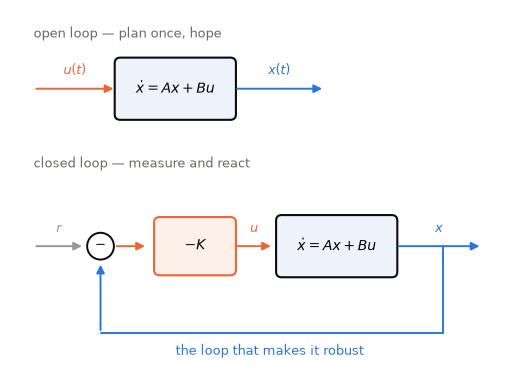

In [3]:
fig, ax = P.panels(figsize=(6.8, 4.0))
P.feedback_diagram(ax)
plt.show()

## 2. The feedback $u=-B^*x$

**Idea.** The feedback removes energy through the observed component, and observability guarantees that this cannot stay small for long.

> **Theorem 1 (stabilization of conservative systems).**
> *Assumptions:* $A^*=-A$, and $(A,B)$ satisfies the Kalman rank condition.
>
> *Conclusion:* $L=-B^*$ stabilizes the system: the solutions of
> $$x'=Ax-BB^*x,\qquad x(0)=x^0,$$
> decay exponentially, $|x(t)|^2\le c\,e^{-\omega t}|x^0|^2$, with explicit constants given below.
>
> *Interpretation:* the feedback removes energy exactly through the observed component $B^*x$, and observability guarantees that this cannot stay small for long.

The proof has three steps. Only the third, the key inequality, uses controllability.

**Step 1: the energy identity.** With $L=-B^*$, and using $\langle Ax,x\rangle=0$,
$$
\frac12\frac{d}{dt}|x(t)|^2=-\langle BB^*x,x\rangle=-|B^*x(t)|^2\le0,
\qquad\text{so}\qquad
|x(T)|^2-|x(0)|^2=-2\int_0^T|B^*x|^2\,dt .
\tag{E}
$$

**Step 2: a contraction over one period implies exponential decay.** Suppose there are $T>0$ and $c>2$ such that
$$
|x(0)|^2\le c\int_0^T|B^*x|^2\,dt\qquad\text{for every solution of the closed loop}.
\tag{K}
$$
Then (E) gives $|x(T)|^2\le\gamma|x(0)|^2$ with $\gamma=1-2/c<1$. The closed loop is autonomous, so the same holds on every interval $[jT,(j+1)T]$, and $|x(jT)|^2\le\gamma^j|x^0|^2$. For $t=jT+\delta$ with $0\le\delta<T$, the norm is non-increasing, so
$$
|x(t)|^2\le|x(jT)|^2\le\gamma^{\,j}|x^0|^2\le\frac1\gamma\,e^{-\omega t}|x^0|^2,\qquad\omega=\frac{|\ln\gamma|}{T},
$$
for the squared norm.

**Step 3: the key inequality (K) from observability.** Split the closed-loop solution as $x=\varphi+y$, where
$$
\varphi'=A\varphi,\ \varphi(0)=x^0,\qquad\qquad y'=Ay-BB^*x,\ y(0)=0 .
$$
The free solution $\varphi$ solves the adjoint system of notebook 03, because $-\varphi'=A^*\varphi$ when $A^*=-A$, except that its datum is given at $t=0$. By observability (notebook 03, §5),
$$
|x^0|^2=|\varphi(0)|^2\le\frac1{c_0}\int_0^T|B^*\varphi|^2\,dt .
$$
Since $\varphi=x-y$, we have $\int|B^*\varphi|^2\le2\int|B^*x|^2+2\int|B^*y|^2$. It remains to bound $y$, which is driven only by $B^*x$:
$$
\int_0^T|B^*y|^2\,dt\le K_T\int_0^T|B^*x|^2\,dt,\qquad K_T=\tfrac12\|B\|^4T^2
$$
(Appendix A). Combining the three inequalities gives (K) with
$$
c=\frac{2}{c_0}\big(1+K_T\big)=\frac{2}{c_0}\Big(1+\tfrac12\|B\|^4T^2\Big). \qquad\square
$$

*Why $c>2$.* By (E), $2\int_0^T|B^*x|^2\le|x^0|^2$, so any constant in (K) satisfies $c\ge2$, and enlarging it gives $c>2$: no large horizon is needed. The proof gives *some* rate, not the best one; the laboratory compares the two.

**Code and plot.** For E1, compare over one period $T=\pi$: the *exact* contraction factor $\gamma_{\rm exact}=\|e^{(A-BB^*)T}\|^2$, the factor $\gamma=1-2/c$ guaranteed by the proof, and the decay they imply. By (E), $\gamma_{\rm exact}=1-2\lambda_{\min}(W_T)$ with $W_T=\int_0^Te^{(A-BB^*)^*t}BB^*e^{(A-BB^*)t}dt$; the code checks this identity as well.

observability constant c_0(T)         = 1.5708
proof: gamma = 1 - 2/c                = 0.7353   -> rate of |x|^2 >= 0.0979
exact contraction over one period     = 6.8970e-02   (1 - 2 lambda_min(W_T) = 6.8947e-02)
true asymptotic rate of |x|^2         = 1.0000


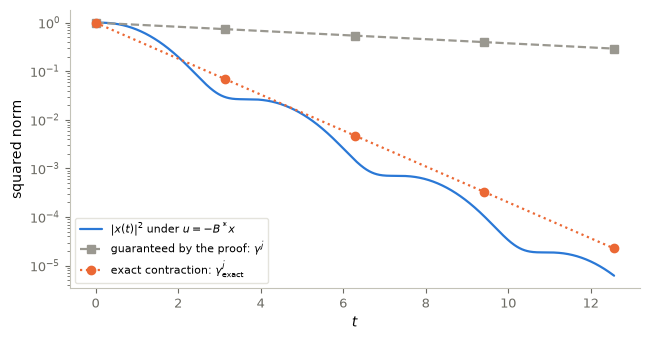

In [4]:
A = torch.tensor([[0.0, 1.0], [-1.0, 0.0]])            # E1: skew-adjoint A, one control
B = torch.tensor([[0.0], [1.0]])
A_cl = A - B @ B.T                                     # closed loop under u = -B^T x = -x2
T_period = float(np.pi)

c0 = obs_constant(A, B, T_period)
c_proof = 2 / c0 * (1 + 0.5 * float(torch.linalg.matrix_norm(B, 2)) ** 4 * T_period ** 2)
gamma_proof = 1 - 2 / c_proof
gamma_exact = float(torch.linalg.matrix_norm(torch.matrix_exp(A_cl * T_period), 2)) ** 2
W = gramian(A_cl.T, B, T_period)                       # int_0^T e^{A_cl^T t} B B^T e^{A_cl t} dt
true_rate = -2 * float(torch.linalg.eigvals(A_cl).real.max())
print(f"observability constant c_0(T)         = {c0:.4f}")
print(f"proof: gamma = 1 - 2/c                = {gamma_proof:.4f}"
      f"   -> rate of |x|^2 >= {abs(np.log(gamma_proof)) / T_period:.4f}")
print(f"exact contraction over one period     = {gamma_exact:.4e}"
      f"   (1 - 2 lambda_min(W_T) = {1 - 2 * float(torch.linalg.eigvalsh(W)[0]):.4e})")
print(f"true asymptotic rate of |x|^2         = {true_rate:.4f}")

x0 = torch.tensor([1.0, 0.0])
ts4 = torch.linspace(0, 4 * T_period, 801)
x_cl = odeint(lambda t, x: A_cl @ x, x0, ts4)
j = np.arange(5)
fig, ax = P.panels(figsize=(6.6, 3.5))
ax.semilogy(ts4, (x_cl ** 2).sum(1), color=P.BLUE, label=r"$|x(t)|^2$ under $u=-B^*x$")
ax.semilogy(j * T_period, gamma_proof ** j, "s--", color=P.GREY,
            label=r"guaranteed by the proof: $\gamma^j$")
ax.semilogy(j * T_period, gamma_exact ** j, "o:", color=P.ORANGE,
            label=r"exact contraction: $\gamma_{\rm exact}^j$")
P.label(ax, "$t$", "squared norm")
plt.show()

The theorem holds, but its constants are far from sharp. The proof guarantees a rate of about $0.1$ for $|x|^2$, while the optimal rate, $-2\max\operatorname{Re}\lambda(A-BB^*)$, is $1$. Both establish *exponential stability*; only the second is the *optimal decay rate*. At multiples of $T$ the solid curve lies below the dots, as it must: the dots are the worst case over all initial states, and $x^0=(1,0)$ is not the worst one. The proof is designed to prove *existence* of a rate from observability, which also works for PDEs where nothing can be computed explicitly. It is not designed to compute the best rate.

## 3. The damped oscillator inside the theory

**Idea.** Velocity feedback fixes the product of the closed-loop roots — that is the overdamping ceiling.

The feedback of Theorem 1 is a damping. For E1, $B^*x=x_2$ is the velocity, so $u=-B^*x$ is the force $-x_2$. Scaling the actuator, $u=-kB^*x$ for any $k>0$, is the same theorem with $B$ replaced by $\sqrt k\,B$: **every positive damping stabilizes**. With mass, stiffness and damping the equation reads
$$
m\,x_1''+k\,x_1'+R\,x_1=0,\qquad m,k,R>0,
$$
an applied force proportional to the velocity and of opposite sign. Its characteristic roots are
$$
r_\pm=\frac{-k\pm\sqrt{k^2-4mR}}{2m},\qquad
\max\operatorname{Re}r_\pm=\begin{cases}-\dfrac{k}{2m}, & k^2\le4mR,\\[6pt]
-\dfrac{k}{2m}+\sqrt{\dfrac{k^2}{4m^2}-\dfrac Rm}, & k^2\ge4mR .\end{cases}
$$

Notebook 01 analyzed the case $m=R=1$ in full. The decay rate is largest at **critical damping** $k=2\sqrt{mR}$, and it tends to $0$ as $k\to\infty$. *Contradicting a first intuition, the decay rate does not increase indefinitely with the damping.*

**Why there is a ceiling: a one-line explanation.** With velocity feedback only, the characteristic polynomial is $m\lambda^2+k\lambda+R$. By Vieta's formulas the **product of the roots is $R/m$, whatever $k$**. As long as the roots are complex they lie on the circle $|\lambda|=\sqrt{R/m}$, with decay rate $k/(2m)$ growing with $k$. They meet at $-\sqrt{R/m}$ when $k=2\sqrt{mR}$. Beyond that they are real with a fixed product: if one moves to $-\infty$, the other must approach $0$. *A single feedback gain cannot move both roots far to the left.*

**Code and plot.** Phase portraits of E1 under $u=-kx_2$ for three dampings, and the closed-loop roots as $k$ grows.

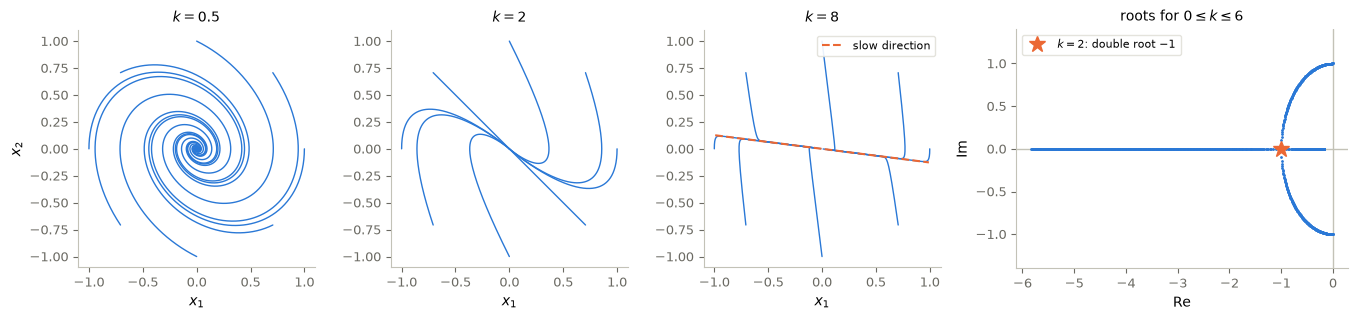

k = 0.5 (underdamped): roots [-0.25+0.9682j -0.25-0.9682j],  spectral rate 0.2500,  fitted slope on [10, 20] 0.2562
k =   2 (critical   ): roots [-1. -1.],  spectral rate 1.0000,  fitted slope on [10, 20] 0.9342


k =   8 (overdamped ): roots [-7.873 -0.127],  spectral rate 0.1270,  fitted slope on [10, 20] 0.1270


In [5]:
ks_phase = [0.5, 2.0, 8.0]
t_long = torch.linspace(0, 20, 2001)
fig, axes = P.panels(4, size=(3.4, 3.3), ratios=[1, 1, 1, 1.4])
for ax, k in zip(axes[:3], ks_phase):
    A_k = torch.tensor([[0.0, 1.0], [-1.0, -k]])
    for angle in np.linspace(0, 2 * np.pi, 8, endpoint=False):
        z0 = torch.tensor([np.cos(angle), np.sin(angle)])
        x_k = odeint(lambda t, x: A_k @ x, z0, t_long)
        ax.plot(x_k[:, 0], x_k[:, 1], color=P.BLUE, lw=1)
    if k > 2:                                          # slow eigendirection of the overdamped system
        lam_slow = (-k + np.sqrt(k * k - 4)) / 2
        v = np.array([1.0, lam_slow]) / np.hypot(1.0, lam_slow)
        ax.plot([-v[0], v[0]], [-v[1], v[1]], "--", color=P.ORANGE, lw=1.5, label="slow direction")
    P.label(ax, "$x_1$", "$x_2$" if k == ks_phase[0] else None, title=f"$k={k:g}$",
            equal=True, xlim=(-1.1, 1.1), ylim=(-1.1, 1.1))

k_grid = np.linspace(0.0, 6.0, 601)
roots = np.array([np.roots([1.0, k, 1.0]) for k in k_grid])
axes[3].plot(roots[:, 0].real, roots[:, 0].imag, ".", ms=2, color=P.BLUE)
axes[3].plot(roots[:, 1].real, roots[:, 1].imag, ".", ms=2, color=P.BLUE)
axes[3].plot([-1], [0], "*", ms=12, color=P.ORANGE, label="$k=2$: double root $-1$")
P.complex_plane(axes[3], title=r"roots for $0 \leq k \leq 6$", ylim=(-1.4, 1.4))

plt.show()

# Reference: the exact spectral rate -max Re(root), checked against the slope of log|x(t)| on [10, 20]
late = t_long >= 10
for k in ks_phase:
    A_k = torch.tensor([[0.0, 1.0], [-1.0, -k]])
    predicted = -np.roots([1.0, k, 1.0]).real.max()
    x_k = odeint(lambda t, x: A_k @ x, torch.tensor([1.0, 0.0]), t_long)
    measured = -np.polyfit(t_long[late].numpy(), np.log(x_k[late].norm(dim=1).numpy()), 1)[0]
    regime = "underdamped" if k < 2 else ("critical" if k == 2 else "overdamped")
    print(f"k = {k:3g} ({regime:11s}): roots {np.round(np.roots([1.0, k, 1.0]), 4)},"
          f"  spectral rate {predicted:.4f},  fitted slope on [10, 20] {measured:.4f}")

For small $k$ the trajectories spiral slowly: the roots sit on the unit circle (product $1$) and move left as $k$ grows. At $k=2$ they collide at $-1$. Beyond, one root runs to $-\infty$ while the other creeps back towards $0$. In the phase portrait for $k=8$, every trajectory is first pushed quickly onto the slow direction (dashed) and then crawls along it to the origin. Twice as much damping is better only below $k=2$. The rates are the spectral ones, $-\max\operatorname{Re}\lambda=0.25$, $1$, $0.127$; the fitted slopes are only a check. At $k=2$ the prefactor $t$ of $(c_1+c_2t)e^{-t}$ biases the finite-window slope low ($0.93$).

## 4. Full-state feedback: pole placement

**Idea.** With all state components in the loop, the closed-loop spectrum is a free design choice.

Theorem 1 assumed $A$ skew-adjoint. The property holds for every matrix:

> **Theorem 2 (pole placement; [Wonham, 1967](https://doi.org/10.1109/TAC.1967.1098739)).**
> *Assumption:* $(A,B)$ is controllable.
>
> *Conclusion:* for any prescribed complex numbers $\lambda_1,\dots,\lambda_n$, with non-real ones in conjugate pairs, there is a feedback matrix $L$ such that the eigenvalues of $A+BL$ are exactly $\lambda_1,\dots,\lambda_n$. In particular, the decay rate can be made arbitrarily fast.
>
> *Interpretation:* this does not contradict overdamping, because *all components of the state* are available to the feedback law. For E1, velocity feedback alone leaves the product of the roots fixed (§3), and the position gain is what moves it.

For E1 the theorem can be done by hand. With $u=-\ell_1x_1-\ell_2x_2$ the closed-loop matrix is $\begin{pmatrix}0&1\\-(1+\ell_1)&-\ell_2\end{pmatrix}$, with characteristic polynomial $\lambda^2+\ell_2\lambda+(1+\ell_1)$. To get roots $p_1,p_2$ we need
$$
\ell_2=-(p_1+p_2),\qquad\ell_1=p_1p_2-1 .
$$
The position gain $\ell_1$ is precisely what changes the product of the roots, the quantity that velocity feedback could not touch.

**Code and plot.** Place a double pole at $-2$ and at $-4$, and compare with the best damping. The decay is faster — what do we pay for it?

velocity only, k = 2 (best damping)    gains L = [ 0. -2.],  eigenvalues [-1.+0.j -1.+0.j],  fitted slope on [3, 6] 0.80,  max|u| = 0.74
full state, poles at -2                gains L = [-3. -4.],  eigenvalues [-2.+0.j -2.+0.j],  fitted slope on [3, 6] 1.78,  max|u| = 3.00
full state, poles at -4                gains L = [-15.  -8.],  eigenvalues [-4.+0.j -4.+0.j],  fitted slope on [3, 6] 3.77,  max|u| = 15.00


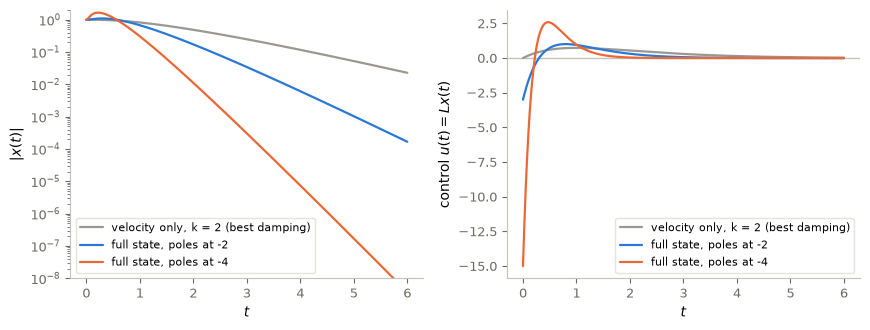

In [6]:
def full_state_gains(p1, p2):
    # u = -l1 x1 - l2 x2 gives the characteristic polynomial lambda^2 + l2 lambda + (1 + l1)
    return p1 * p2 - 1.0, -(p1 + p2)

designs = {"velocity only, k = 2 (best damping)": torch.tensor([[0.0, -2.0]])}
for p in (-2.0, -4.0):
    l1, l2 = full_state_gains(p, p)
    designs[f"full state, poles at {p:g}"] = torch.tensor([[-l1, -l2]])

t_short = torch.linspace(0, 6, 1201)
fig, (ax1, ax2) = P.panels(2, size=(4.4, 3.4))
for (name, L), color in zip(designs.items(), (P.GREY, P.BLUE, P.ORANGE)):
    A_L = A + B @ L
    eig = torch.linalg.eigvals(A_L)
    x_L = odeint(lambda t, x: A_L @ x, x0, t_short)
    u_L = x_L @ L.T
    ax1.semilogy(t_short, x_L.norm(dim=1) + 1e-300, color=color, label=name)
    ax2.plot(t_short, u_L[:, 0], color=color, label=name)
    late = t_short > 3
    fitted = -np.polyfit(t_short[late].numpy(), np.log(x_L[late].norm(dim=1).numpy()), 1)[0]
    print(f"{name:38s} gains L = {L.numpy().ravel()},  eigenvalues {np.round(eig.numpy(), 4)},"
          f"  fitted slope on [3, 6] {fitted:.2f},  max|u| = {float(u_L.abs().max()):.2f}")
P.label(ax1, "$t$", "$|x(t)|$", ylim=(1e-8, 2))
P.label(ax2, "$t$", "control $u(t)=Lx(t)$", zero="h")
plt.show()

Full-state feedback beats critical damping, and the rate is set by the chosen poles: exactly $1$, $2$ and $4$. The slopes fitted on $[3,6]$ are biased low by the factor $t$ of each double pole. The price is the gain. Placing the poles at $-4$ needs gains $(15,8)$ and a peak control $|u|=15$, about twenty times the peak of the best damping; the norm $|x(t)|$ even grows at first before it decays. Large gains amplify any error in the measured state (notebook 01, Exercise 3). And, as H. R. Hall remarked about governors in 1907, a regulator should diminish fluctuations, not try to remove them altogether. Fast is not free — §6 makes this trade-off the *definition* of the design.

## 5. Controllability is not stabilizability

**Idea.** Only the modes the input cannot reach need to decay by themselves.

Theorems 1–2 *assume* controllability. Is it necessary for stabilization? No, and the recurring example E2 shows why. At $\varepsilon=0$,
$$
A=\begin{pmatrix}0&1&0\\-1&0&0\\0&0&-1\end{pmatrix},\qquad B_0=\begin{pmatrix}0\\1\\0\end{pmatrix},
$$
the pair is **not controllable** (notebook 02, §8): the input never reaches $x_3$. But that mode decays by itself, $x_3'=-x_3$. The feedback $u=-B_0^*x$ damps the oscillator, and the closed loop has eigenvalues $(-1\pm i\sqrt3)/2$ and $-1$: **E2 at $\varepsilon=0$ is stabilizable**.

By contrast, if the uncontrollable mode were unstable, say $x_3'=+x_3$, no feedback whatsoever could stabilize the system. The equation for $x_3$ does not involve $u$, so the eigenvalue $+1$ stays in the spectrum of $A+B_0L$ for every $L$.

**The general statement in finite dimension** *(stated without proof)*. The reachable subspace $\mathcal R=\operatorname{Range}[B,AB,\dots,A^{n-1}B]$ is invariant under $A$, and under $A+BL$ for every $L$. The eigenvalues of the map that $A$ induces on the quotient $\mathbb R^n/\mathcal R$, the **uncontrollable modes**, remain eigenvalues of $A+BL$ whatever $L$ is. The pair $(A,B)$ is **stabilizable** if and only if every uncontrollable mode has negative real part. Controllability, $\mathcal R=\mathbb R^n$, is the case with no uncontrollable mode at all. For E2 at $\varepsilon=0$, $\mathcal R=\operatorname{span}\{e_1,e_2\}$ and the only uncontrollable mode is $-1$.

So controllability ≠ stabilizability. Controllability is sufficient for stabilization, and it allows every rate (Theorem 2). Stabilizability only asks that the modes the input cannot reach decay on their own.

**Code and check.** The two variants of E2 at $\varepsilon=0$.

In [7]:
A2 = torch.tensor([[0.0, 1.0, 0.0], [-1.0, 0.0, 0.0], [0.0, 0.0, -1.0]])
B2 = torch.tensor([[0.0], [1.0], [0.0]])
print("E2 at eps = 0: Kalman rank", int(torch.linalg.matrix_rank(kalman(A2, B2))), "of 3")
print("closed-loop eigenvalues with u = -B0^T x:",
      np.round(torch.linalg.eigvals(A2 - B2 @ B2.T).numpy(), 6))

A2_unstable = A2.clone(); A2_unstable[2, 2] = 1.0      # the uncontrollable mode made unstable
L_try = torch.tensor([[-3.0, -5.0, 7.0]])              # any feedback whatsoever
print("unstable variant, closed-loop eigenvalues for an arbitrary L:",
      np.round(torch.linalg.eigvals(A2_unstable + B2 @ L_try).numpy(), 6))

E2 at eps = 0: Kalman rank 2 of 3
closed-loop eigenvalues with u = -B0^T x: [-0.5+0.866025j -0.5-0.866025j -1. +0.j      ]
unstable variant, closed-loop eigenvalues for an arbitrary L: [-1.+0.j -4.+0.j  1.+0.j]


## 6. Linear quadratic regulator

**Idea.** Balance state error and input effort through a quadratic cost — the cost chooses the poles.

Pole placement leaves the choice of poles to us, and §4 showed that aggressive choices cost large gains. The **linear quadratic regulator** turns the trade-off itself into the design:

$$ \min_{u(\cdot)} \; J(u) = \int_0^\infty \Big( x(t)^\top Q\, x(t) + u(t)^\top R\, u(t) \Big) dt
\qquad \text{s.t.} \qquad \dot x = Ax + Bu, \;\; x(0)=x^0, $$

with $Q = Q^\top \succeq 0$ weighting how much we dislike being away from the origin and $R = R^\top \succ 0$ weighting how much we dislike spending input. The ratio between them is the only design knob, and it has units an engineer can reason about.

### 6.1 Optional derivation: completing the square

Take any symmetric $P$ and consider the quantity $x^\top P x$ along a trajectory:

$$ \frac{d}{dt}\big(x^\top P x\big) = x^\top(A^\top P + PA)x + 2\,x^\top P B u .$$

If the control stabilizes the system then $x(t) \to 0$, so
$\int_0^\infty \frac{d}{dt}(x^\top Px)\,dt = -(x^0)^\top P x^0$. Adding zero in this form,

$$ J(u) = (x^0)^\top P x^0 + \int_0^\infty \Big[ x^\top\big(Q + A^\top P + PA\big)x + 2x^\top PBu + u^\top R u \Big] dt .$$

The bracket is a quadratic in $u$; complete the square using $R \succ 0$:

$$ u^\top R u + 2 x^\top P B u = \big\|u + R^{-1}B^\top P x\big\|_R^2 - x^\top P B R^{-1} B^\top P x ,$$

so that

$$ J(u) = (x^0)^\top P x^0
  + \int_0^\infty \Big[ x^\top \underbrace{\big(A^\top P + PA - PBR^{-1}B^\top P + Q\big)}_{\text{choose } P \text{ to kill this}} x
  \;+\; \big\|u + R^{-1}B^\top P x\big\|_R^2 \Big] dt .$$

Now **define** $P$ to be the symmetric positive semidefinite solution of the **algebraic Riccati equation**

$$ \boxed{\; A^\top P + P A - P B R^{-1} B^\top P + Q = 0 .\;} $$

The first integrand vanishes identically and we are left with $J(u) = (x^0)^\top P x^0 + \int_0^\infty \|u + Kx\|_R^2\,dt$ with $K = R^{-1}B^\top P$. Every term is non-negative, so

$$ J(u) \;\ge\; (x^0)^\top P x^0 \quad\text{for all } u, \qquad\text{with equality iff}\qquad
   \boxed{\; u^\star(t) = -K x(t), \quad K = R^{-1}B^\top P .\;} $$

Two things follow immediately. The optimal control is a **linear state feedback**. The optimal cost is the quadratic form $V(x) = x^\top P x$, which is the **value function** of the problem and doubles as a Lyapunov function for the closed loop.

The standard existence assumptions are **stabilizability** of $(A,B)$ — the notion of §5 — and **detectability** of $(Q^{1/2},A)$ ([Åström and Murray, 2021](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html)). Controllability is a sufficient condition for stabilizability, but it is stronger than necessary. With $Q \succ 0$, an uncontrollable unstable mode gives infinite cost for initial states with a component in that mode.

### 6.2 Solving the Riccati equation

The ARE is quadratic in $P$, so it has several solutions and we want the stabilizing one. The standard route is the $2n \times 2n$ **Hamiltonian matrix**

$$ H = \begin{bmatrix} A & -BR^{-1}B^\top \\ -Q & -A^\top \end{bmatrix} ,$$

whose spectrum is symmetric about the imaginary axis. Take a basis $\begin{bmatrix}X_1\\X_2\end{bmatrix}$ of the invariant subspace belonging to the $n$ eigenvalues with negative real part; then $P = X_2X_1^{-1}$.

**Code and check.** Compute the LQR gain for E1 and compare the predicted optimal cost $(x^0)^\top Px^0$ with the cost integrated along the closed-loop trajectory.

In [8]:
def care(A, B, Q, R):
    """Stabilising solution of AᵀP + PA − PBR⁻¹BᵀP + Q = 0, via the Hamiltonian matrix."""
    n = A.shape[0]
    H = torch.cat([torch.cat([A, -B @ torch.linalg.solve(R, B.T)], dim=1),
                   torch.cat([-Q, -A.T], dim=1)], dim=0)
    w, V = torch.linalg.eig(H)
    stable = torch.argsort(w.real)[:n]                 # the n eigenvalues with Re < 0
    U = V[:, stable]
    return (U[n:] @ torch.linalg.inv(U[:n])).real

def lqr(A, B, Q, R):
    P_ = care(A, B, Q, R)
    return torch.linalg.solve(R, B.T @ P_), P_         # K, P

Q, R = torch.eye(2), torch.tensor([[1.0]])
K_lqr, P_lqr = lqr(A, B, Q, R)

residual = A.T @ P_lqr + P_lqr @ A - P_lqr @ B @ torch.linalg.solve(R, B.T @ P_lqr) + Q
print("P  =\n", P_lqr.numpy().round(4))
print("K  =", K_lqr.numpy().ravel().round(4))
print("ARE residual norm =", f"{float(residual.norm()):.2e}")
print("closed-loop poles =", np.round(torch.linalg.eigvals(A - B @ K_lqr).numpy(), 4))
print(f"\noptimal cost from x0:  x0ᵀ P x0 = {float(x0 @ P_lqr @ x0):.4f}")

ts_fb = torch.linspace(0, 12, 1201)
traj_lqr = odeint(lambda t, x: (A - B @ K_lqr) @ x, x0, ts_fb)
u_l = -(traj_lqr @ K_lqr.T).squeeze(-1)
J_num = torch.trapezoid(((traj_lqr @ Q) * traj_lqr).sum(-1) + u_l ** 2 * R[0, 0], ts_fb)
print(f"cost integrated along the trajectory  = {float(J_num):.4f}")

P  =
 [[1.9123 0.4142]
 [0.4142 1.3522]]
K  = [0.4142 1.3522]
ARE residual norm = 1.15e-14
closed-loop poles = [-0.6761+0.9783j -0.6761-0.9783j]

optimal cost from x0:  x0ᵀ P x0 = 1.9123
cost integrated along the trajectory  = 1.9123


The two numbers agree, which is the derivation checking itself: $(x^0)^\top P x^0$ really is the value of the optimal cost.

Two more facts worth knowing. First, the **finite-horizon** problem
$\int_0^T(x^\top Qx + u^\top Ru)\,dt + x(T)^\top Q_T x(T)$ has a *time-varying* solution
$u = -R^{-1}B^\top P(t)x$, where $P$ solves the **differential Riccati equation** backwards from the terminal condition:

$$ -\dot P = A^\top P + PA - PBR^{-1}B^\top P + Q, \qquad P(T) = Q_T . $$

As the horizon grows, $P(t)$ settles onto the constant solution of the algebraic equation — the infinite-horizon regulator is the long-horizon limit, a first glimpse of the **turnpike** phenomenon of [notebook 08](08_long_time_control_turnpike.ipynb). Second, sweeping $R$ traces the closed-loop poles along the **symmetric root locus**: for $R \to \infty$ (input is precious) they approach the stable reflections of the open-loop poles; as $R \to 0$ (input is cheap), some poles move far left while others can approach finite limits.

Everything so far has rested on one assumption: the model is **linear**.

## 7. The nonlinear case: model predictive control

**Idea.** Plan ahead using the nonlinear model, then replan after the next measurement.

Real systems are of the form

$$ \dot x = f(x, u), \qquad u(t) \in \mathcal{U} \subset \mathbb{R}^m, $$

where $f$ is nonlinear and $\mathcal{U}$ is the set of admissible inputs. Nonlinear accessibility can involve Lie-bracket conditions (notebook 02, §10), and controllability requires additional care. In the undiscounted infinite-horizon setting, the value function is described by the Hamilton–Jacobi–Bellman PDE

$$ \min_{u \in \mathcal{U}} \Big\{ \ell(x,u) + \nabla V(x)^\top f(x,u) \Big\} = 0 , $$

which for $n$ more than a handful cannot be solved on a grid. LQR is the lucky special case where the HJB equation has a finite-dimensional closed form.

**Model predictive control** takes the pragmatic route. Rather than solve for the feedback law $u = \pi(x)$ everywhere, solve a finite-horizon optimal control problem *at the state you are actually in*, numerically, right now:

$$
\begin{aligned}
\min_{u(\cdot)} \;\; & \int_t^{t+T} \ell\big(x(s), u(s)\big)\, ds \;+\; V_f\big(x(t+T)\big) \\
\text{s.t.} \;\; & \dot x = f(x,u), \quad x(t) = \hat x(t), \quad u(s) \in \mathcal{U} .
\end{aligned}
$$

Then throw almost all of it away: apply only $u^\star$ on $[t, t + \Delta)$, measure the state again, and re-solve from there. Planning far ahead but committing only to the next step is what turns an open-loop plan into a feedback law. It is also what makes MPC tolerate the model being slightly wrong.

> **The test problem: holding a pendulum upright.**
> A bob of mass $M$ on a massless rod of length $L$ pivots freely, so its moment of inertia is $ML^2$. The angle $\theta$ is measured **from the upright**: $\theta = 0$ is the unstable equilibrium and $\theta = \pi$ is the pendulum hanging at rest. With a torque $u$ applied at the pivot, $ML^2\ddot\theta = MgL\sin\theta - b ML^2\dot\theta + u$, i.e.
> $$ \ddot\theta = \frac{g}{L}\sin\theta \;-\; b\,\dot\theta \;+\; \frac{u}{ML^2}, \qquad |u| \le u_{\max}. $$
> Linearising at the top ($\sin\theta \approx \theta$) gives
> $$ A_p = \begin{bmatrix} 0 & 1 \\ g/L & -b \end{bmatrix}, \qquad    B_p = \begin{bmatrix} 0 \\ 1/ML^2 \end{bmatrix} . $$

**Code and animation.** Apply the saturated law $u = \operatorname{sat}(-Kx)$, designed by LQR on the linearization, to the true nonlinear pendulum, started at rest from two nearby angles. (A full MPC swing-up from $\theta=\pi$ is Exercise 7.)

In [9]:
G_GRAV, L_ROD, M_ROD, DAMP = 9.81, 1.0, 1.0, 0.10
U_MAX = 3.0                                    # M g L = 9.81, so we have well under a third of it

def f_pend(x, u):
    """x = (θ, ω) with θ measured from upright; u = torque. Batched over leading dims."""
    return torch.stack([x[..., 1],
                        (G_GRAV / L_ROD) * torch.sin(x[..., 0]) - DAMP * x[..., 1]
                        + u[..., 0] / (M_ROD * L_ROD ** 2)], dim=-1)

def step_pend(x, u, h):                        # one RK4 step with a zero-order-hold input
    k1 = f_pend(x, u); k2 = f_pend(x + h / 2 * k1, u)
    k3 = f_pend(x + h / 2 * k2, u); k4 = f_pend(x + h * k3, u)
    return x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)

wrap = lambda a: torch.remainder(a + np.pi, 2 * np.pi) - np.pi     # angle into (−π, π]

A_p = torch.tensor([[0.0, 1.0], [G_GRAV / L_ROD, -DAMP]])
B_p = torch.tensor([[0.0], [1.0 / (M_ROD * L_ROD ** 2)]])
Q_p, R_p = torch.diag(torch.tensor([10.0, 1.0])), torch.tensor([[0.1]])
K_p, P_p = lqr(A_p, B_p, Q_p, R_p)

print("upright is unstable:  eig(A_p) =", np.round(torch.linalg.eigvals(A_p).numpy(), 3))
print("controllable:", int(torch.linalg.matrix_rank(kalman(A_p, B_p))) == 2)
print("LQR gain K =", np.round(K_p.numpy().ravel(), 3),
      "  closed-loop poles =", np.round(torch.linalg.eigvals(A_p - B_p @ K_p).numpy(), 3))

upright is unstable:  eig(A_p) = [ 3.082+0.j -3.182+0.j]
controllable: True
LQR gain K = [23.818  7.493]   closed-loop poles = [-3.161+0.j -4.431+0.j]


In [10]:
def run_lqr(theta0, t_end=6.0, h=0.02):
    """Saturated LQR on the nonlinear pendulum, started at rest from theta0."""
    x, xs = torch.tensor([theta0, 0.0]), []
    for _ in range(int(t_end / h)):
        u = torch.clamp(-K_p @ torch.stack([wrap(x[0]), x[1]]), -U_MAX, U_MAX)
        x = step_pend(x, u, h); xs.append(x)
    return torch.stack(xs)

P.animate_pendulum([run_lqr(0.30)[:, 0], run_lqr(0.40)[:, 0]], dt=0.02,
                   frames=range(0, 300, 3), trail=20,
                   labels=[r"$\theta_0 = 0.30$", r"$\theta_0 = 0.40$"])

The linear law, designed only from the linearization at the top and saturated at a third of the gravity torque, catches the pendulum from both initial angles: feedback forgives the model being wrong *near* the operating point. It cannot swing the pendulum up from $\theta=\pi$ — that requires planning with the nonlinear model, which is exactly what MPC adds (Exercise 7).

## 8. Control ↔ ML: damping and momentum

**Idea.** Momentum methods are damped second-order dynamics on a loss landscape.

Gradient descent with **momentum** can be pictured as a heavy ball rolling down the loss landscape. Its continuous-time model is a damped second-order equation in which the gradient of the loss plays the role of the spring. The overdamping lesson of this notebook, too little damping oscillates and too much creeps, reappears there as the problem of choosing the momentum parameter. The analogy is structural, not an identity. Feedback stabilization designs the damping of a given physical system, whereas a momentum method chooses a parameter of an optimization algorithm whose "spring" is a loss landscape. Its mathematics belongs to [notebook 11](11_optimization.ipynb).

**From MPC to reinforcement learning.** MPC needs the model $f$. When you do not have it, you can learn it from data and plan through it — exactly the neural ODE of [notebook 13](13_neuralodes.ipynb) dropped into `f_pend` above — or skip the model and learn the value function or policy directly from interaction. The HJB equation that MPC approximates numerically is the same equation that the Bellman backup of [notebook 18](18_reinforcement_learning.ipynb) approximates statistically.

## 9. What we left out

**Idea.** The same tools extend to state estimation and to constrained control.

- **Observers and the Kalman filter.** We assumed the full state $x$ was measurable. It rarely is. With an output $y=Cx$, Kalman's companion condition asks that $[C;CA;\dots;CA^{n-1}]$ have rank $n$ — exactly controllability of $(A^\top,C^\top)$, the duality of notebook 03 seen from the other side. An **observer** $\dot{\hat x} = A\hat x + Bu + L_{\rm obs}(y - C\hat x)$ reconstructs the state, $L_{\rm obs}$ is designed by placing the poles of $A - L_{\rm obs}C$, and the *separation principle* says the controller and observer can be designed independently. With process and measurement noise, the optimal $L_{\rm obs}$ solves a Riccati equation dual to the LQR one: that is the **Kalman filter** ([Kalman, 1960](https://doi.org/10.1115/1.3662552)).
- **Constraints as first-class citizens.** We met the torque limit only by saturating a linear law. Real MPC uses QP/NLP solvers, handles state constraints, and constructs terminal sets that guarantee recursive feasibility ([Rawlings, Mayne and Diehl, 2017](https://sites.engineering.ucsb.edu/~jbraw/mpc/)).
- **Infinite dimensions.** For PDEs, stabilization by $-B^*$ feedback survives (the proof of Theorem 1 was designed for it), while pole placement does not. The observability inequalities it needs are the subject of [notebook 07](07_adjoints_density_heat_control.ipynb).

## 10. Common misconceptions

**"More damping is always better."** Only up to critical damping. Velocity feedback cannot change the product of the characteristic roots (§3).

**"Pole placement contradicts overdamping."** It uses *all* state components. Velocity feedback alone is limited; full-state feedback is not (§4).

**"Feedback can bring the state exactly to rest at a chosen time."** Not with an autonomous linear feedback: its solutions never vanish in finite time from $x^0\ne0$ (§1). Exact steering in finite time is an open-loop task (notebooks 02–04).

**"Uncontrollable means unstabilizable."** E2 at $\varepsilon=0$ is uncontrollable but stabilizable, because its unreachable mode is stable (§5).

**"The rate in the proof of Theorem 1 is the actual rate."** It is a guaranteed lower bound, far from sharp (§2).

**"LQR removes the need to choose anything."** It moves the choice from pole locations to the weights $(Q,R)$ — a better-conditioned choice, not an absent one (§6).

## 11. Key takeaways

1. Stabilization: find $L$ with $|x(t)|\le ce^{-\omega t}|x^0|$ for $x'=(A+BL)x$. An autonomous linear feedback decays exponentially, but never reaches $0$ in finite time from $x^0\ne0$.
2. For $A^*=-A$ and $(A,B)$ controllable, $u=-B^*x$ stabilizes: energy identity $+$ observability ⇒ contraction over one period ⇒ exponential decay. The rate guaranteed by the proof is valid but pessimistic.
3. Damping $u=-kx_2$ is this feedback. Velocity feedback fixes the product of the roots, which is why the decay rate peaks at critical damping $k=2\sqrt{mR}$.
4. Full-state feedback places the poles anywhere (Theorem 2), at the price of large gains.
5. Controllability is sufficient but not necessary for stabilization: stabilizability requires only that the uncontrollable modes be stable.
6. LQR chooses the feedback through a quadratic cost: $u^\star=-R^{-1}B^\top Px$ with $P$ the stabilizing solution of the Riccati equation, and the optimal cost is $(x^0)^\top Px^0$.
7. MPC repeatedly plans a finite-horizon trajectory with the nonlinear model and applies only its first part; stability guarantees require additional conditions.

## 12. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Position feedback. ★** Can the oscillator E1 be stabilized by feedback on the *position* only, $u=-\ell x_1$? Answer from the characteristic polynomial, and interpret physically.
2. **What velocity feedback cannot do. ★★** For E1, show that no velocity feedback $u=-kx_2$ can place both closed-loop poles at $-2$, and that full-state feedback can. Compute the gains for poles $p_1=-1$, $p_2=-3$, and check them numerically.
3. **A spectral proof of Theorem 1. ★★** Let $A^*=-A$ and $(A,B)$ controllable. (a) Show that every eigenvalue $\lambda$ of $A-BB^*$ satisfies $\operatorname{Re}\lambda\le0$. *Hint:* compute $v^*(A-BB^*)v$ for an eigenvector $v$. (b) Show that $\operatorname{Re}\lambda=0$ would force $B^*v=0$ and $Av=\lambda v$, and that this contradicts the Kalman condition. (c) Deduce Theorem 1 in finite dimension. Why does this argument not extend to PDEs, while the proof of §2 does?
4. **The unstable uncontrollable mode. ★★** For the unstable variant of E2 (§5), show that for *every* feedback matrix $L\in\mathbb R^{1\times3}$ the number $+1$ is an eigenvalue of $A+B_0L$. *Hint:* look at the third row of $A+B_0L$.
5. **How sharp is the proof? ★★★** For E1 under $u=-B^*x$, compute for $T\in[0.5,20]$ the exact contraction $\gamma_{\rm exact}(T)=\|e^{(A-BB^*)T}\|^2$ and the factor $\gamma(T)=1-2/c(T)$ guaranteed by the proof (§2), with $c(T)=\tfrac{2}{c_0(T)}\big(1+\tfrac12T^2\big)$. Plot the guaranteed rates $|\ln\gamma(T)|/T$ and $|\ln\gamma_{\rm exact}(T)|/T$ against $T$. Which $T$ gives the best guaranteed rate, and how far is it from the true rate $1$?
6. **LQR weights. ★★★** Increase the LQR input weight $R$ for E1. Plot the closed-loop response and the input for several values, and explain which quantity becomes more expensive as $R$ grows. Where do the closed-loop poles go as $R\to\infty$, and as $R\to0$?
7. **Model predictive control. ★★★** Swing the pendulum up from $\theta = \pi$. Optimize the inputs over a 5 s horizon by direct shooting: write $u_j = u_{\max}\tanh(v_j)$, roll out `step_pend`, and minimize the cost with `torch.optim`, differentiating through the rollout. Apply the first few inputs, re-solve from the new state, and switch to the LQR law once the pendulum is near the top.

In [11]:
# TODO: student exercise (Exercise 5)
# For T on a grid in [0.5, 20], compute c0(T) with obs_constant(A, B, T), the proof's
# gamma(T) = 1 - 2/c(T), and gamma_exact(T) = ||expm(A_cl T)||_2^2; plot |ln gamma|/T for both.

def guaranteed_rate(T_):
    ...  # your code here
    return None

## Where are we going?

This closes Part I. Every control in notebooks 02–05 came from a **minimization principle** (HUM, $J_{bb}$, $J_{sw}$, the LQR cost) or from an **energy identity** (feedback). [Notebook 06](06_variational_principles_gradient_flows.ipynb) studies these two ideas in their own right: when a minimizer exists, and how following the gradient, a gradient flow and its discretization, gradient descent, finds it. Its Lyapunov function plays the role of the energy here, and the same mechanism will later become the training of learning machines.

## Appendix A — The estimate for $y$, with explicit constants

We prove $\int_0^T|B^*y|^2\le\tfrac12\|B\|^4T^2\int_0^T|B^*x|^2$ for $y'=Ay-BB^*x$, $y(0)=0$, with $A^*=-A$. Since $\langle Ay,y\rangle=0$,
$$
\frac12\frac{d}{dt}|y|^2=-\langle B^*x,B^*y\rangle\le|B^*x|\,\|B\|\,|y| .
$$
Hence $\frac{d}{dt}|y|\le\|B\|\,|B^*x|$ wherever $y\ne0$. Rigorously, apply the same computation to $\sqrt{|y|^2+\delta^2}$ and let $\delta\to0$. Integrating, and using Cauchy–Schwarz,
$$
|y(t)|\le\|B\|\int_0^t|B^*x|\,ds\le\|B\|\,\sqrt t\,\Big(\int_0^T|B^*x|^2\Big)^{1/2}.
$$
Therefore
$$
\int_0^T|B^*y|^2\le\|B\|^2\int_0^T|y|^2\le\|B\|^4\Big(\int_0^Tt\,dt\Big)\int_0^T|B^*x|^2=\tfrac12\|B\|^4T^2\int_0^T|B^*x|^2 .
$$

## References

**Stabilization and pole placement**

1. R. E. Kalman, [*Contributions to the theory of optimal control*](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf), Boletín de la Sociedad Matemática Mexicana **5** (1960), 102–119. *(controllability; LQR)*
2. R. E. Kalman, [*A new approach to linear filtering and prediction problems*](https://doi.org/10.1115/1.3662552), Journal of Basic Engineering **82** (1960), 35–45.
3. W. M. Wonham, [*On pole assignment in multi-input controllable linear systems*](https://doi.org/10.1109/TAC.1967.1098739), IEEE Transactions on Automatic Control **12** (1967), 660–665.
4. J. Ackermann, [*Der Entwurf linearer Regelungssysteme im Zustandsraum*](https://doi.org/10.1524/auto.1972.20.112.297), Regelungstechnik **20** (1972), 297–300.
5. H. Nyquist, [*Regeneration theory*](https://doi.org/10.1002/j.1538-7305.1932.tb02344.x), Bell System Technical Journal **11** (1932), 126–147.
6. H. W. Bode, [*Network Analysis and Feedback Amplifier Design*](https://openlibrary.org/books/OL6485104M/Network_analysis_and_feedback_amplifier_design), Van Nostrand, 1945.

**LQR**

7. B. D. O. Anderson, J. B. Moore, [*Optimal Control: Linear Quadratic Methods*](https://researchportalplus.anu.edu.au/en/publications/optimal-control-linear-quadratic-methods/), Prentice-Hall, 1990.
8. M. G. Safonov, M. Athans, [*Gain and phase margin for multiloop LQG regulators*](https://ntrs.nasa.gov/citations/19770047955), IEEE Transactions on Automatic Control **22** (1977), 173–179.

**Model predictive control**

9. J. Richalet, A. Rault, J. L. Testud, J. Papon, [*Model predictive heuristic control: applications to industrial processes*](https://doi.org/10.1016/0005-1098(78)90001-8), Automatica **14** (1978), 413–428.
10. D. Q. Mayne, J. B. Rawlings, C. V. Rao, P. O. M. Scokaert, [*Constrained model predictive control: stability and optimality*](https://doi.org/10.1016/S0005-1098(99)00214-9), Automatica **36** (2000), 789–814.
11. J. B. Rawlings, D. Q. Mayne, M. M. Diehl, [*Model Predictive Control: Theory, Computation, and Design*](https://sites.engineering.ucsb.edu/~jbraw/mpc/), 2nd ed., Nob Hill Publishing, 2017.

**Textbooks**

12. E. D. Sontag, [*Mathematical Control Theory: Deterministic Finite Dimensional Systems*](https://doi.org/10.1007/978-1-4612-0577-7), 2nd ed., Springer, 1998.
13. K. J. Åström, R. M. Murray, [*Feedback Systems: An Introduction for Scientists and Engineers*](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html), 2nd ed., Princeton University Press, 2021.